<a href="https://colab.research.google.com/github/diak224-dot/Machine-Learning-Projects/blob/main/DIAK_test3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 : Réseaux de neurones convolutifs (CNN)

## Objectif

L'objectif de ce TP est de mettre en œuvre un réseau de neurones convolutif (CNN) afin de résoudre un problème de classification d'images à l'aide du dataset MNIST.

Le TP permet de comprendre :

- le fonctionnement des couches de convolution ;
- le rôle des couches de pooling ;
- la préparation des données pour un CNN ;
- l'entraînement et l'évaluation d'un modèle ;
- l'analyse des performances à l'aide de différentes métriques.

#**Partie 1 — Chargement et comprehension du dataset**

In [1]:
# =========================================================
# Modules nécessaires
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import tensorflow as tf

# Chargement du dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de y_train :", y_train.shape)

print("Nombre de classes :", len(np.unique(y_train)))

print("Taille d'une image :", X_train[0].shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensions de X_train : (60000, 28, 28)
Dimensions de y_train : (60000,)
Nombre de classes : 10
Taille d'une image : (28, 28)


# Réponses aux questions

### 1. Combien d'images contient le dataset d'entraînement ?

Le dataset d'entraînement contient 60 000 images.

### 2. Quelle est la taille de chaque image en pixels ?

Chaque image possède une taille de 28 × 28 pixels.

### 3. Quelle est la différence entre X_train et y_train ?

- X_train contient les images.
- y_train contient les étiquettes correspondant aux chiffres représentés dans les images.

### 4. Pourquoi ce problème est-il considéré comme un problème de classification multi-classes ?

Parce que le modèle doit reconnaître 10 classes différentes correspondant aux chiffres de 0 à 9.

#**Partie 2 — Préparation des données**

In [2]:
# Ajout de la dimension canal

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Conversion en float32

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalisation

X_train /= 255.0
X_test /= 255.0

# One-Hot Encoding

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (60000, 28, 28, 1)
X_test : (10000, 28, 28, 1)
y_train : (60000, 10)
y_test : (10000, 10)


# Réponses aux questions

### 1. Pourquoi doit-on ajouter une dimension de canal ?

Les couches CNN attendent des données sous la forme :
(nombre_images, hauteur, largeur, canaux).

Même pour une image en niveaux de gris, il faut préciser qu'il existe un seul canal.

### 2. Quel est le rôle de la division par 255 ?

Elle permet de normaliser les pixels entre 0 et 1.

Cette normalisation accélère l'apprentissage et améliore la stabilité du réseau.

### 3. Que représente l'encodage one-hot ?

Chaque classe est représentée par un vecteur.

Exemple :

Chiffre 3 :

[0,0,0,1,0,0,0,0,0,0]

Cela facilite l'apprentissage dans un problème multi-classes.

#**Partie 3 — Visualisation de quelques échantillons**

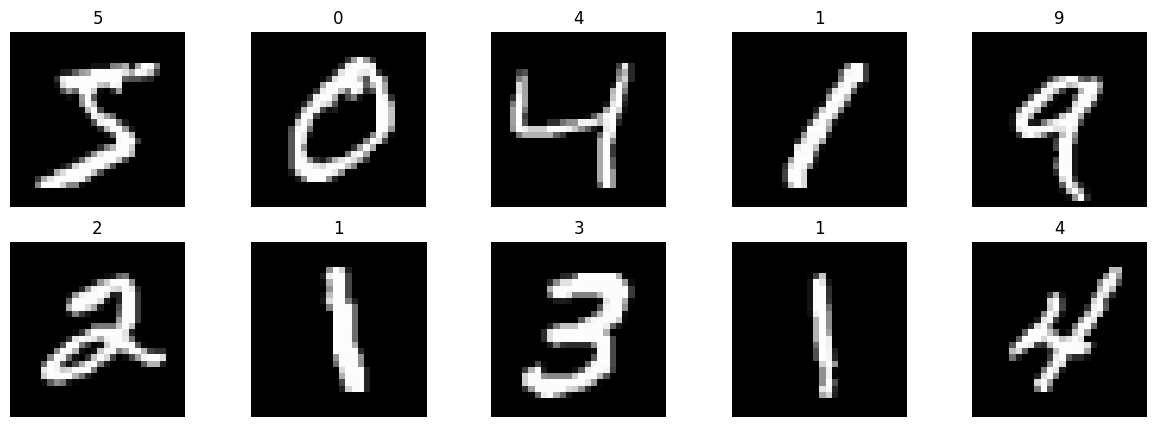

In [3]:
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i].reshape(28,28),
               cmap='gray')

    plt.title(np.argmax(y_train[i]))
    plt.axis('off')

plt.show()

# Réponses aux questions

### 1. Pourquoi visualiser les données ?

La visualisation permet de vérifier que les données ont été correctement chargées et prétraitées.

### 2. Quelles différences observe-t-on entre les chiffres manuscrits ?

Les styles d'écriture varient selon les personnes :

- épaisseur des traits ;
- inclinaison ;
- taille ;
- forme générale.

### 3. Pourquoi utiliser cmap='gray' ?

Parce que les images du dataset MNIST sont en niveaux de gris.

#**Partie4 — Construction du réseau CNN**

In [4]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(Flatten())

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

# Réponses aux questions

### 1. Pourquoi la couche d'entrée dépend-elle de la taille des images ?

Parce que le réseau doit connaître les dimensions exactes des données reçues.

### 2. Quel est le rôle des couches de convolution et de pooling ?

- Convolution : extraction des caractéristiques importantes.
- Pooling : réduction de la taille des données et du coût de calcul.

### 3. Pourquoi utiliser ReLU ?

ReLU accélère l'apprentissage et évite certains problèmes liés aux gradients.

### 4. Pourquoi utiliser Softmax ?

Softmax transforme les sorties en probabilités dont la somme est égale à 1.

#**Partie 5 — Compilation du modèle**

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Réponses aux questions

### 1. Quel est le rôle de la fonction de perte ?

Elle mesure l'erreur entre les prédictions du modèle et les vraies réponses.

### 2. Pourquoi utiliser categorical_crossentropy ?

Parce que nous avons un problème de classification multi-classes.

### 3. Quel est le rôle de l'optimiseur Adam ?

Adam ajuste automatiquement les poids du réseau afin de minimiser l'erreur.

### 4. Que mesure accuracy ?

Accuracy représente le pourcentage de prédictions correctes.

#**Partie 6 — Entraînement du modèle**

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9167 - loss: 0.2902 - val_accuracy: 0.9668 - val_loss: 0.1175
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9728 - loss: 0.0926 - val_accuracy: 0.9783 - val_loss: 0.0784
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9817 - loss: 0.0618 - val_accuracy: 0.9817 - val_loss: 0.0638
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9858 - loss: 0.0470 - val_accuracy: 0.9824 - val_loss: 0.0592
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.9836 - val_loss: 0.0557
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9916 - loss: 0.0287 - val_accuracy: 0.9854 - val_loss: 0.0508
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9929 - loss: 0.0237 - val_accuracy: 0.9837 - val_loss: 0.0549
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9952 - loss: 0.0169 - 

# Réponses aux questions

### 1. Que signifie une époque ?

Une époque correspond à un passage complet sur toutes les données d'entraînement.

### 2. Quel est le rôle du batch_size ?

Les données sont traitées par groupes afin de réduire le temps de calcul.

### 3. Pourquoi utiliser un ensemble de validation ?

Il permet d'évaluer le modèle pendant l'entraînement sans utiliser les données de test.

### 4. Que peut-il se passer si le nombre d'epochs est trop élevé ?

Le modèle peut sur-apprendre (overfitting) et perdre sa capacité de généralisation.

#**Partie 7 — Visualisation par la courbe de perte**

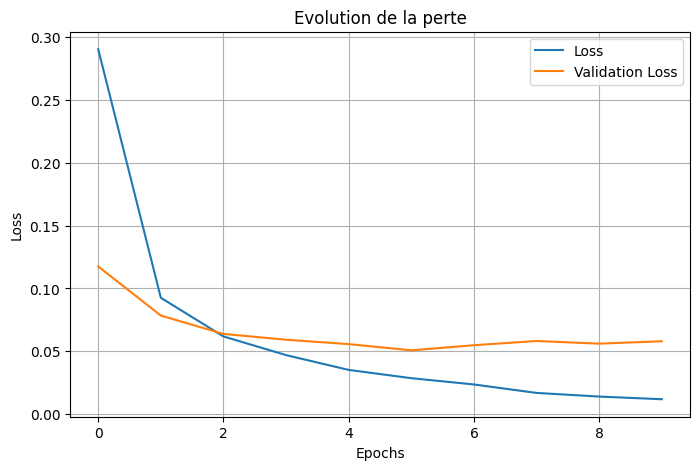

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Evolution de la perte")

plt.legend()
plt.grid()

plt.show()

# Réponses aux questions

### 1. Que représente la courbe de perte ?

Elle montre l'évolution de l'erreur du modèle pendant l'entraînement.

### 2. Comment savoir si le modèle apprend correctement ?

La perte doit diminuer progressivement.

### 3. Comment détecter un surapprentissage ?

Lorsque la courbe val_loss augmente alors que la loss continue de diminuer.

### 4. Pourquoi la perte de validation est-elle importante ?

Elle permet d'évaluer la capacité du modèle à généraliser sur de nouvelles données.

#**Partie 8 — Évaluation du modèle**

In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9843 - loss: 0.0513
Test Loss : 0.0513051338493824
Test Accuracy : 0.9843000173568726


# Réponses aux questions

### 1. Pourquoi évaluer sur les données de test ?

Pour mesurer les performances réelles du modèle sur des données jamais vues.

### 2. Différence entre accuracy d'entraînement et accuracy de test ?

- Accuracy d'entraînement : performance sur les données utilisées pour apprendre.
- Accuracy de test : performance sur de nouvelles données.

### 3. Que signifie une accuracy élevée ?

Le modèle effectue un grand nombre de prédictions correctes.

### 4. Une accuracy élevée suffit-elle ?

Non. Il faut également analyser les erreurs et les autres métriques.

#**Partie 9 — Prédictions et rapport de classification**

In [10]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print(
    "Accuracy :",
    accuracy_score(
        np.argmax(y_test, axis=1),
        y_pred
    )
)

print("\nRapport de classification :\n")

print(
    classification_report(
        np.argmax(y_test, axis=1),
        y_pred
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Accuracy : 0.9843

Rapport de classification :

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Réponses aux questions

### 1. Pourquoi le modèle retourne-t-il des probabilités ?

Parce que Softmax produit une probabilité pour chaque classe.

### 2. Quel est le rôle de argmax ?

Elle sélectionne la classe ayant la probabilité la plus élevée.

### 3. Différence entre précision, rappel et F1-score ?

- Précision : qualité des prédictions positives.
- Rappel : capacité à retrouver les vraies classes.
- F1-score : compromis entre précision et rappel.

### 4. Pourquoi le F1-score est-il utile ?

Il fournit une mesure équilibrée des performances du modèle.

#**Partie 10 — Matrice de confusion**

In [11]:
cm = confusion_matrix(
    np.argmax(y_test, axis=1),
    y_pred
)

print(cm)

[[ 968    0    4    0    0    1    3    1    3    0]
 [   0 1126    2    1    1    0    3    0    2    0]
 [   0    1 1019    1    1    0    0    7    3    0]
 [   0    0    1 1001    0    4    0    1    3    0]
 [   0    1    1    0  977    0    2    0    0    1]
 [   1    0    1    7    0  874    5    1    2    1]
 [   7    2    2    0    1    3  942    0    1    0]
 [   0    2    7    2    1    0    0 1015    0    1]
 [   5    0    1    1    0    1    1    2  961    2]
 [   1    1    3    6   12    5    0   13    8  960]]


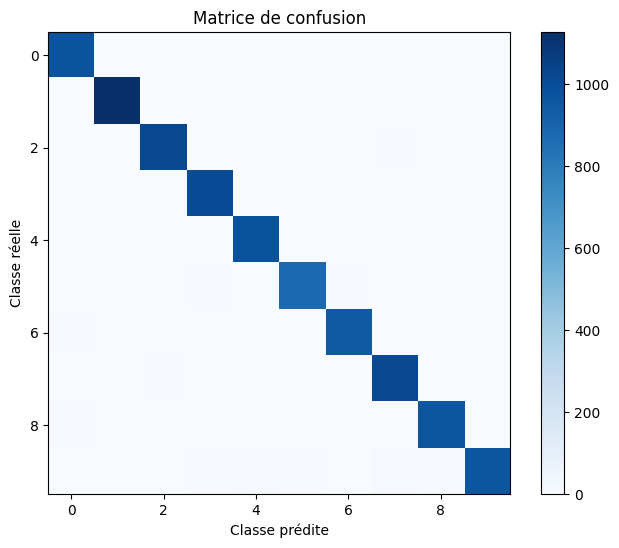

In [12]:
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap='Blues')

plt.title("Matrice de confusion")

plt.colorbar()

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")

plt.show()

# Réponses aux questions

### 1. Que représente une matrice de confusion ?

Elle montre le nombre de prédictions correctes et incorrectes pour chaque classe.

### 2. Différence entre bonne et mauvaise classification ?

- Bonne classification : classe prédite = classe réelle.
- Mauvaise classification : classe prédite ≠ classe réelle.

### 3. Quels chiffres peuvent être confondus ?

Par exemple :

- 3 et 5
- 4 et 9
- 7 et 1

lorsque l'écriture manuscrite est ambiguë.

### 4. Comment utiliser la matrice de confusion ?

Elle permet d'identifier les classes les plus difficiles à reconnaître et d'améliorer le modèle.